In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import norm
from scipy.signal import butter, filtfilt

# Paths
results_path = "kilosort4_imec_ap_20260626_LGN_exp_job46234680\\sorter_output"
dat_path = "kilosort4_imec_ap_20260626_LGN_exp_job46234680\\sorter_output\\recording.dat"
bin_path = "C:\\SGL_DATA\\20260626_LGN_exp_g0\\20260626_LGN_exp_g0_imec0\\20260626_LGN_exp_g0_t0.imec0.ap.bin"
output_path = "kilosort4_imec_ap_20260626_LGN_exp_job46234680\\QC_figures"
os.makedirs(output_path, exist_ok=True)

# Parameters
sample_rate = 25000.0
# Placeholders: will auto-detect channel counts after loading templates/spike_times
n_channels = None
n_channels_total = None

# Load spike sorting data
templates = np.load(f"{results_path}/templates.npy")
spike_times = np.load(f"{results_path}/spike_times.npy").flatten()
spike_clusters = np.load(f"{results_path}/spike_clusters.npy").flatten()
amplitudes = np.load(f"{results_path}/amplitudes.npy").flatten()
channel_positions = np.load(f"{results_path}/channel_positions.npy")
pc_features = np.load(f"{results_path}/pc_features.npy")
pc_feature_ind = np.load(f"{results_path}/pc_feature_ind.npy")
# Auto-detect channel counts from loaded data
try:
    n_channels = int(templates.shape[1])
except Exception:
    n_channels = 31
# infer total channels from .bin file size when possible
n_channels_total = n_channels
try:
    if os.path.exists(bin_path) and spike_times.size > 0:
        size = os.path.getsize(bin_path)
        duration_samples = int(spike_times.max() + 1)
        possible_nch = int(size / (duration_samples * 2)) if duration_samples > 0 else n_channels
        if possible_nch >= n_channels:
            n_channels_total = possible_nch
except Exception:
    n_channels_total = n_channels

# Load good units
labels = {}
with open(f"{results_path}/cluster_KSLabel.tsv") as f:
    next(f)
    for line in f:
        uid, label = line.strip().split('\t')
        labels[int(uid)] = label
good_units = [uid for uid, label in labels.items() if label == 'good']

print(f"Loaded! {len(good_units)} good units: {good_units}")
print(f"PC features shape: {pc_features.shape}")

Loaded! 127 good units: [7, 14, 15, 23, 25, 31, 32, 34, 36, 37, 39, 41, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56, 57, 61, 63, 64, 65, 66, 67, 68, 74, 75, 76, 79, 80, 82, 83, 84, 85, 86, 87, 88, 93, 94, 95, 96, 98, 100, 102, 103, 104, 105, 109, 111, 113, 116, 117, 119, 120, 123, 124, 126, 127, 128, 130, 131, 132, 133, 136, 137, 138, 140, 141, 142, 143, 144, 145, 149, 150, 151, 152, 153, 156, 157, 158, 159, 160, 163, 165, 166, 167, 171, 179, 194, 196, 199, 200, 205, 207, 212, 213, 218, 222, 223, 225, 234, 239, 264, 266, 268, 269, 273, 275, 280, 284, 285, 293, 294, 295, 309, 323, 330, 331, 334, 336, 346]
PC features shape: (14322667, 6, 10)


In [2]:
def read_raw_chunk_dat(dat_path, start_sample, n_samples, n_channels):
    """Read chunk from recording.dat (preprocessed, 31 channels)"""
    with open(dat_path, 'rb') as f:
        f.seek(start_sample * n_channels * 2)
        data = np.frombuffer(f.read(n_samples * n_channels * 2), dtype=np.int16)
    return data.reshape(n_samples, n_channels).astype(float)

def read_raw_chunk_bin(bin_path, start_sample, n_samples, n_channels_total, n_channels):
    """Read chunk from .bin file (raw, 35 channels), return only neural channels"""
    with open(bin_path, 'rb') as f:
        f.seek(start_sample * n_channels_total * 2)
        data = np.frombuffer(f.read(n_samples * n_channels_total * 2), dtype=np.int16)
    data = data.reshape(n_samples, n_channels_total).astype(float)
    return data[:, :n_channels]

def lowpass_filter(data, cutoff, fs, order=3):
    nyq = fs / 2
    cut = min(cutoff / nyq, 0.99)
    b, a = butter(order, cut, btype='low')
    return filtfilt(b, a, data, axis=0)

def highpass_filter(data, cutoff, fs, order=3):
    nyq = fs / 2
    cut = cutoff / nyq
    b, a = butter(order, cut, btype='high')
    return filtfilt(b, a, data, axis=0)

print("Filter functions ready!")

Filter functions ready!


In [3]:
def make_qc_figure_final(unit_id):

    # Get spikes for this unit
    mask = spike_clusters == unit_id
    unit_spike_times = spike_times[mask]
    unit_amplitudes = amplitudes[mask]
    unit_spike_indices = np.where(mask)[0]
    n_spikes = len(unit_spike_times)

    if n_spikes < 10:
        print(f"Unit {unit_id}: too few spikes, skipping")
        return

    # Template and channels
    template = templates[unit_id]
    peak_amps = np.max(np.abs(template), axis=0)
    main_ch = int(np.argmax(peak_amps))
    top4_channels = np.argsort(peak_amps)[-4:][::-1]
    # Safety checks: ensure indices are within available channels in the template
    nch_template = template.shape[1]
    top4_channels = [int(ch) for ch in top4_channels if int(ch) < nch_template]
    if len(top4_channels) == 0:
        top4_channels = [min(main_ch, nch_template - 1)]
    main_ch = int(min(main_ch, nch_template - 1))

    # RPVs
    isi_ms = np.diff(unit_spike_times) / sample_rate * 1000
    rpv_count = np.sum(isi_ms < 2.0)
    rpv_pct = rpv_count / n_spikes * 100

    # Autocorrelogram
    max_lag_ms = 100
    bin_size_ms = 1
    bins = np.arange(-max_lag_ms, max_lag_ms + bin_size_ms, bin_size_ms)
    acg = np.zeros(len(bins) - 1)
    spike_times_sec = unit_spike_times / sample_rate
    for t in spike_times_sec[:500]:
        diffs = (spike_times_sec - t) * 1000
        diffs = diffs[(diffs != 0) & (np.abs(diffs) <= max_lag_ms)]
        acg += np.histogram(diffs, bins=bins)[0]
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Firing rate
    recording_duration = spike_times.max() / sample_rate
    bin_size_sec = 60
    n_bins = int(recording_duration / bin_size_sec) + 1
    firing_rate_bins = np.zeros(n_bins)
    for st in unit_spike_times:
        bin_idx = int(st / sample_rate / bin_size_sec)
        if bin_idx < n_bins:
            firing_rate_bins[bin_idx] += 1
    firing_rate_bins = firing_rate_bins / bin_size_sec
    bin_times_min = np.arange(n_bins) * bin_size_sec / 60

    # PC scatter
    other_indices = np.where(~mask)[0]
    n_sample = min(2000, len(unit_spike_indices), len(other_indices))
    sample_unit = np.random.choice(unit_spike_indices, n_sample, replace=False)
    sample_other = np.random.choice(other_indices, n_sample, replace=False)
    unit_pcs = pc_features[sample_unit]
    other_pcs = pc_features[sample_other]

    # ── Raw data window ──
    # Fix 1: randomly select a spike instead of always using middle
    rand_spike = unit_spike_times[np.random.randint(len(unit_spike_times))]

    # Fix 2: read longer window then trim edges to remove filter artifacts
    window_sec = 1.0       # read 1 full second
    trim_sec = 0.25        # discard 0.25s from each end
    n_raw = int(window_sec * sample_rate)
    trim_samples = int(trim_sec * sample_rate)
    start_sample = max(int(trim_sec * sample_rate),
                       int(rand_spike - window_sec/2 * sample_rate))

    # LFP from .bin file (raw unfiltered)
    raw_bin = read_raw_chunk_bin(bin_path, start_sample, n_raw,
                                  n_channels_total, n_channels)
    raw_bin = raw_bin - raw_bin.mean(axis=0)
    lfp_full = lowpass_filter(raw_bin, 300, sample_rate)
    lfp_data = lfp_full[trim_samples:-trim_samples, :]  # trim edges

    # HP from recording.dat (already preprocessed, no 60Hz noise)
    raw_dat = read_raw_chunk_dat(dat_path, start_sample, n_raw, n_channels)
    raw_dat = raw_dat - raw_dat.mean(axis=0)
    hp_full = highpass_filter(raw_dat, 300, sample_rate)
    hp_data = hp_full[trim_samples:-trim_samples, :]  # trim edges

    # Robust channel clipping: compute actual nch in raw files
    lfp_nch = lfp_data.shape[1] if lfp_data.ndim > 1 else 0
    hp_nch = hp_data.shape[1] if hp_data.ndim > 1 else 0
    avail_ch_raw = min(lfp_nch, hp_nch, template.shape[1])
    if avail_ch_raw <= 0:
        print(f"Unit {unit_id}: no raw channels available, skipping")
        return
    # Clip top channels to what's available in the raw recordings
    top4_channels = [int(ch) for ch in top4_channels if int(ch) < avail_ch_raw]
    if len(top4_channels) == 0:
        top4_channels = [min(main_ch, avail_ch_raw - 1)]
    main_ch = int(min(main_ch, avail_ch_raw - 1))

    # Spikes in trimmed window
    trimmed_start = start_sample + trim_samples
    trimmed_end = start_sample + n_raw - trim_samples
    window_spikes = unit_spike_times[
        (unit_spike_times >= trimmed_start) &
        (unit_spike_times < trimmed_end)
    ]
    window_spikes_rel = (window_spikes - trimmed_start) / sample_rate
    time_axis = np.arange(len(lfp_data)) / sample_rate

    # ── Create figure ──
    fig = plt.figure(figsize=(24, 10))
    fig.suptitle(f'Unit {unit_id} | Ch{main_ch} | N spikes: {n_spikes} | RPVs: {rpv_count} ({rpv_pct:.1f}%)',
                 fontsize=14, fontweight='bold')
    gs = fig.add_gridspec(2, 6, hspace=0.45, wspace=0.35)

    # Row 1, Panel 1: Waveforms 4 channels
    ax1 = fig.add_subplot(gs[0, 0])
    colors4 = ['steelblue', 'darkorange', 'green', 'red']
    for i, ch in enumerate(top4_channels):
        ax1.plot(template[:, ch], color=colors4[i], alpha=0.8, label=f'ch{ch}')
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax1.set_xlabel('Samples')
    ax1.set_ylabel('Amplitude')
    ax1.set_title(f'{n_spikes} spikes (RPVs={rpv_count}, {rpv_pct:.1f}%)')
    ax1.legend(fontsize=7)

    # Row 1, Panel 2: Autocorrelogram
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(bin_centers, acg, width=bin_size_ms, color='black', edgecolor='none')
    ax2.axvline(0, color='red', linewidth=1.5)
    ax2.set_xlabel('Time lag (ms)')
    ax2.set_ylabel('Count')
    ax2.set_title('Autocorrelogram')
    ax2.set_xlim(-max_lag_ms, max_lag_ms)

    # Row 1, Panel 3: Raw LFP from .bin (trimmed)
    ax3 = fig.add_subplot(gs[0, 2])
    # guard main_ch against lfp data width
    main_ch_lfp = min(main_ch, lfp_data.shape[1]-1) if lfp_data.ndim>1 else 0
    ax3.plot(time_axis, lfp_data[:, main_ch_lfp], color='black', linewidth=0.8)
    for spike_t in window_spikes_rel:
        idx = min(int(spike_t * sample_rate), len(lfp_data)-1)
        ax3.plot(spike_t, lfp_data[idx, main_ch_lfp], 'r*', markersize=10)
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Amplitude')
    ax3.set_title(f'Raw LFP (ch{main_ch_lfp})')

    # Row 1, Panels 4-6: PC scatter row 1
    pc_pairs = [(0, 1), (0, 2), (1, 2)]
    for col, (pa, pb) in enumerate(pc_pairs):
        ax = fig.add_subplot(gs[0, 3+col])
        ax.scatter(other_pcs[:, pa, 0], other_pcs[:, pb, 0],
                   s=1, alpha=0.3, color='yellow')
        ax.scatter(unit_pcs[:, pa, 0], unit_pcs[:, pb, 0],
                   s=1, alpha=0.5, color='cyan')
        ax.set_xlabel(f'PC{pa+1}')
        ax.set_ylabel(f'PC{pb+1}')
        ax.set_title(f'PC{pa+1} vs PC{pb+1}')
        ax.set_facecolor('black')

    # Row 2, Panel 1: Amplitude histogram
    ax4 = fig.add_subplot(gs[1, 0])
    n, bins_amp, _ = ax4.hist(unit_amplitudes, bins=50, color='steelblue',
                                edgecolor='none', alpha=0.7)
    mu, std = norm.fit(unit_amplitudes)
    x = np.linspace(unit_amplitudes.min(), unit_amplitudes.max(), 200)
    bin_width = bins_amp[1] - bins_amp[0]
    gaussian = norm.pdf(x, mu, std) * n_spikes * bin_width
    ax4.plot(x, gaussian, 'r-', linewidth=2)
    cutoff = unit_amplitudes.min()
    missing_frac = norm.cdf(cutoff, mu, std)
    missing_pct = missing_frac / max(1 - missing_frac, 1e-9) * 100
    ax4.axvline(cutoff, color='k', linestyle='--', linewidth=1.5)
    ax4.set_xlabel('Amplitude')
    ax4.set_ylabel('No. of spikes')
    ax4.set_title(f'Est. missing spikes: {missing_pct:.1f}%')

    # Row 2, Panel 2: Amplitude over time + firing rate
    ax5 = fig.add_subplot(gs[1, 1])
    spike_times_min = unit_spike_times / sample_rate / 60
    ax5.scatter(spike_times_min, unit_amplitudes, s=1, alpha=0.2, color='steelblue')
    ax5.set_xlabel('Time (min)')
    ax5.set_ylabel('Amplitude', color='steelblue')
    ax5.tick_params(axis='y', labelcolor='steelblue')
    ax5b = ax5.twinx()
    ax5b.plot(bin_times_min, firing_rate_bins, color='darkorange',
              linewidth=1.5, alpha=0.8)
    ax5b.set_ylabel('Firing rate (Hz)', color='darkorange')
    ax5b.tick_params(axis='y', labelcolor='darkorange')
    ax5.set_title('Amplitude + Firing rate')

    # Row 2, Panel 3: HP from recording.dat (trimmed)
    ax6 = fig.add_subplot(gs[1, 2])
    colors_hp = ['steelblue', 'darkorange', 'green', 'red']
    # compute std across available hp channels safely
    safe_hp_channels = [ch for ch in top4_channels if ch < hp_data.shape[1]]
    if len(safe_hp_channels) == 0:
        safe_hp_channels = [min(main_ch, hp_data.shape[1]-1)]
    try:
        std_hp = np.max([hp_data[:, ch].std() for ch in safe_hp_channels])
    except Exception:
        std_hp = hp_data.std(axis=0).max() if hp_data.size else 1.0
    for i, ch in enumerate(safe_hp_channels):
        ch_data = np.clip(hp_data[:, ch], -3*std_hp, 3*std_hp)
        offset = i * std_hp * 6
        ax6.plot(time_axis, ch_data + offset,
                 color=colors_hp[i], linewidth=0.5, alpha=0.9, label=f'ch{ch}')
    for spike_t in window_spikes_rel:
        ax6.axvline(spike_t, color='red', alpha=0.6, linewidth=1.0)
    ax6.set_xlabel('Time (s)')
    ax6.set_title('High-pass filtered (4 ch)')
    ax6.set_yticks([])
    ax6.legend(fontsize=6, loc='upper right')

    # Row 2, Panels 4-6: PC scatter row 2
    pc_pairs2 = [(3, 0), (3, 1), (3, 2)]
    for col, (pa, pb) in enumerate(pc_pairs2):
        ax = fig.add_subplot(gs[1, 3+col])
        ax.scatter(other_pcs[:, pa, 0], other_pcs[:, pb, 0],
                   s=1, alpha=0.3, color='yellow')
        ax.scatter(unit_pcs[:, pa, 0], unit_pcs[:, pb, 0],
                   s=1, alpha=0.5, color='cyan')
        ax.set_xlabel(f'PC{pa+1}')
        ax.set_ylabel(f'PC{pb+1}')
        ax.set_title(f'PC{pa+1} vs PC{pb+1}')
        ax.set_facecolor('black')

    plt.savefig(f'{output_path}/QCfinal_unit{unit_id}.png',
                dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved QC final figure for Unit {unit_id}")

In [4]:
print("Generating final QC figures...")
for unit_id in good_units:
    make_qc_figure_final(unit_id)
print(f"\nDone! All figures saved to {output_path}")

Generating final QC figures...
Saved QC final figure for Unit 7
Saved QC final figure for Unit 14
Saved QC final figure for Unit 15
Saved QC final figure for Unit 23
Saved QC final figure for Unit 25
Saved QC final figure for Unit 31
Saved QC final figure for Unit 32
Saved QC final figure for Unit 34
Saved QC final figure for Unit 36
Saved QC final figure for Unit 37
Saved QC final figure for Unit 39
Saved QC final figure for Unit 41
Saved QC final figure for Unit 44
Saved QC final figure for Unit 45
Saved QC final figure for Unit 46
Saved QC final figure for Unit 47
Saved QC final figure for Unit 48
Saved QC final figure for Unit 49
Saved QC final figure for Unit 51
Saved QC final figure for Unit 52
Saved QC final figure for Unit 54
Saved QC final figure for Unit 55
Saved QC final figure for Unit 56
Saved QC final figure for Unit 57
Saved QC final figure for Unit 61
Saved QC final figure for Unit 63
Saved QC final figure for Unit 64
Saved QC final figure for Unit 65
Saved QC final fig

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jerrywang/Downloads/spike_sorting_results/firing_rate_heatmap.png'

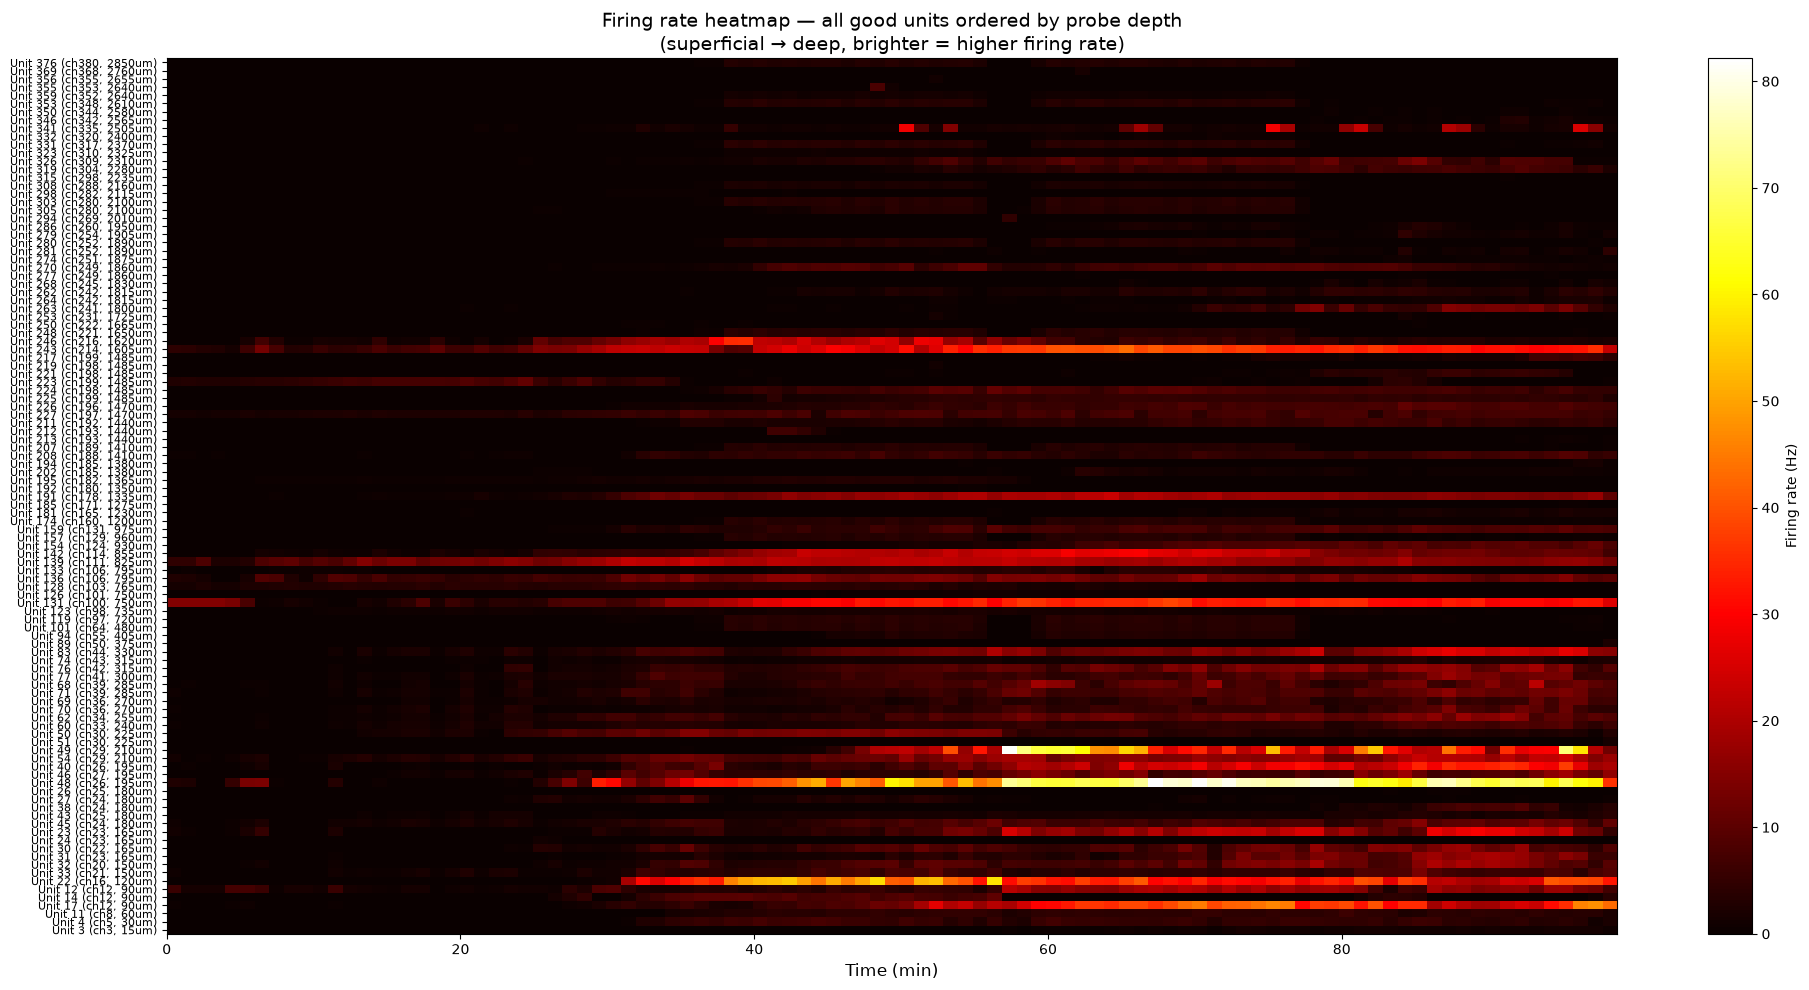

In [ ]:
# Build unit depth ordering --> temporarily not in use!!
unit_depths = []
for unit_id in good_units:
    template = templates[unit_id]
    peak_amps = np.max(np.abs(template), axis=0)
    main_ch = int(np.argmax(peak_amps))
    # Guard against mismatched channel_positions
    if ('channel_positions' in globals() or 'channel_positions' in locals()) and channel_positions is not None and channel_positions.shape[0] > main_ch:
        depth = channel_positions[main_ch, 1]
    else:
        depth = float('nan')
    unit_depths.append((unit_id, main_ch, depth))

unit_depths_sorted = sorted(unit_depths, key=lambda x: x[2], reverse=True)

# Firing rate heatmap
fig, ax = plt.subplots(figsize=(20, 10))

bin_size_min = 1.0
total_min = spike_times.max() / sample_rate / 60
n_time_bins = int(total_min / bin_size_min) + 1

firing_rate_matrix = np.zeros((len(unit_depths_sorted), n_time_bins))
for y_pos, (unit_id, main_ch, depth) in enumerate(unit_depths_sorted):
    mask = spike_clusters == unit_id
    unit_st = spike_times[mask] / sample_rate / 60
    for spike_t in unit_st:
        bin_idx = int(spike_t / bin_size_min)
        if bin_idx < n_time_bins:
            firing_rate_matrix[y_pos, bin_idx] += 1
    firing_rate_matrix[y_pos, :] /= bin_size_min * 60

im = ax.imshow(firing_rate_matrix, aspect='auto',
               extent=[0, total_min, len(unit_depths_sorted)-0.5, -0.5],
               cmap='hot', interpolation='nearest')

plt.colorbar(im, ax=ax, label='Firing rate (Hz)')
ax.set_yticks(range(len(unit_depths_sorted)))
ax.set_yticklabels([f'Unit {uid} (ch{ch}, {int(d)}um)'
                    for uid, ch, d in unit_depths_sorted], fontsize=8)
ax.set_xlabel('Time (min)', fontsize=12)
ax.set_title('Firing rate heatmap — all good units ordered by probe depth\n(superficial → deep, brighter = higher firing rate)',
             fontsize=14)
plt.tight_layout()
plt.savefig('/Users/jerrywang/Downloads/spike_sorting_results/firing_rate_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")